In [1]:
import pandas as pd

messages=pd.read_csv('spamclassificationmaster\SMSSpamCollection.csv',
                    sep='\t',names=["label","message"])

<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\anshb\AppData\Local\Temp\ipykernel_29872\1188409859.py:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  messages=pd.read_csv('spamclassificationmaster\SMSSpamCollection.csv',


## Data Cleaning and Preprocessing

1. We have Message coloumn that contains text 
2. Lower all the words 
3. do text preprocessing ( regular expressions , Tokenize )

In [2]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anshb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer


stopwords_english = stopwords.words('english')
ps = PorterStemmer()
lem = WordNetLemmatizer()

### Steps to follow :
1. go through each sentences in messages ( remove the special characters )
2. Lower the words 
3. remove stopwords 
4. Stemming 

In [4]:
corpus_steming = []
for i in range(0,len(messages)):
    review = re.sub('[^a-zA-Z]',' ',messages['message'][i])    #subsititue any special character with a blank
    review = review.lower()
    review = review.split()    # split each word
    review = [ps.stem(word) for word in review if word not in stopwords_english]   # stemming and removing stop words
    review = ' '.join(review)

    corpus_steming.append(review)

In [5]:
corpus_steming

['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
 'ok lar joke wif u oni',
 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
 'u dun say earli hor u c alreadi say',
 'nah think goe usf live around though',
 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv',
 'even brother like speak treat like aid patent',
 'per request mell mell oru minnaminungint nurungu vettam set callertun caller press copi friend callertun',
 'winner valu network custom select receivea prize reward claim call claim code kl valid hour',
 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free',
 'gonna home soon want talk stuff anymor tonight k cri enough today',
 'six chanc win cash pound txt csh send cost p day day tsandc appli repli hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw',
 'search right word thank breather

In [6]:
corpus_lemmetize = []
for i in range(0,len(messages)):
    review = re.sub('[^a-zA-Z]',' ',messages['message'][i])
    review = review.lower()
    review = review.split()

    review = [lem.lemmatize(word,pos='n') for word in review if word not in stopwords_english]
    review = ' '.join(review)

    corpus_lemmetize.append(review)

In [7]:
corpus_lemmetize

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think go usf life around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aid patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hour',
 'mobile month u r entitled update latest colour mobile camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw'

## Creating the Bag of words

key parameters we need to keep track of:
1. n_grams 
2. max_features
3. lower 
4. stopwords 
5. binary 

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=2500,binary=True)  # vocabulary size is 2500 now ( top 2500 words with most frequency ) and the bag of words which will be created is Binary

In [9]:
X_stemming = cv.fit_transform(corpus_steming).toarray()   # this is not a binary bag of words!!!

In [10]:
X_stemming

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 2500))

In [11]:
X_lemmetize = cv.fit_transform(corpus_lemmetize).toarray()

In [12]:
X_lemmetize

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 2500))

In [13]:
messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [14]:
messages['label'] = messages['label'].map({'ham': 0, 'spam': 1})

In [15]:
messages

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [16]:
y = messages['label']

from sklearn.model_selection import train_test_split

X_stemming_train , X_stemming_test , y_train , y_test = train_test_split(X_stemming,y,random_state=42,test_size=0.30)
X_lemmetize_train , X_lemmetize_test , y_train_lm , y_test_lm = train_test_split(X_lemmetize,y,random_state=42,test_size=0.30)

In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

def evaluate_model(y_true,y_pred):
    acc = accuracy_score(y_true=y_true , y_pred=y_pred)
    cm = confusion_matrix(y_pred=y_pred,y_true=y_true)
    cr = classification_report(y_pred=y_pred,y_true=y_true)

    return acc , cm , cr

In [ ]:
from sklearn import naive_bayes
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    'logistic Regression' : LogisticRegression(),
    'svc': SVC(),
    'naive bias ': naive_bayes.MultinomialNB(),
    'ada boost classifier ':AdaBoostClassifier()
}

model_list = []
r2_list =[]
print('='*35)
print('-'*15+'STEMMING'+'-'*15)
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_stemming_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_stemming_train)
    y_test_pred = model.predict(X_stemming_test)
    
    # Evaluate Train and Test dataset
    model_train_acc_score , model_train_confusion_matrix, model_train_cr = evaluate_model(y_train, y_train_pred)

    model_test_acc_score , model_test_confusion_matrix , model_test_cr = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- accuracy score : {:.4f}".format(model_train_acc_score))
    print("- confusion matrix : \n{}".format(model_train_confusion_matrix))
    print("- classification report : \n{}".format(model_train_cr))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- accuracy score : {:.4f}".format(model_test_acc_score))
    print("- confusion matrix : \n{}".format(model_test_confusion_matrix))
    print("- classification report : \n{}".format(model_test_cr))
    r2_list.append(model_test_acc_score)
    
    print('='*35)
    print('\n')

---------------STEMMING---------------


lr
Model performance for Training set
- accuracy score : 0.9946
- confusion matrix : 
[[3377    0]
 [  21  502]]
- classification report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3377
           1       1.00      0.96      0.98       523

    accuracy                           0.99      3900
   macro avg       1.00      0.98      0.99      3900
weighted avg       0.99      0.99      0.99      3900

----------------------------------
Model performance for Test set
- accuracy score : 0.9844
- confusion matrix : 
[[1447    1]
 [  25  199]]
- classification report : 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.99      0.89      0.94       224

    accuracy                           0.98      1672
   macro avg       0.99      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672



svc
Model performance for Training s

## Observations 

1. Logistic Regression 
2. Naive Bias 

are really performing well.

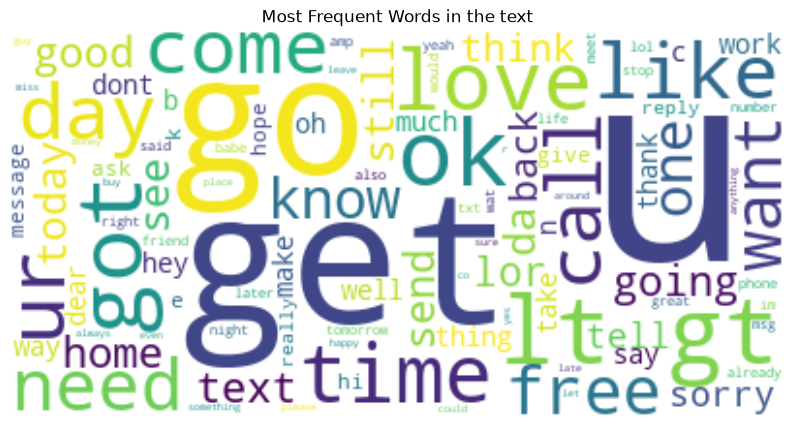

In [27]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
corpus_lemmetize_string = ' '.join(corpus_lemmetize)
wc = WordCloud(stopwords=stopwords_english, background_color="white", max_words=100).generate(corpus_lemmetize_string)

plt.figure(figsize=(10,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in the text")
plt.show()